<a href="https://colab.research.google.com/github/aqilfiras/SMS-Classification/blob/main/SMS_Spam_CLS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn as nn
import gensim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, f1_score
from sklearn.linear_model import LogisticRegression
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Change device to 'cuda' if available

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option('future.no_silent_downcasting', True)

# Get the data

In [5]:
data = pd.read_csv('spam.csv', encoding='latin-1')
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
data = data.rename(columns={'v1': 'label', 'v2': 'text'})
print(data['label'].value_counts())
data = data.replace({'ham': 0, 'spam': 1})
data.head()

label
ham     4825
spam     747
Name: count, dtype: int64


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Set values for x and y

In [6]:
y_raw,X_raw = data['label'].copy().tolist(), data['text'].copy().str.lower().tolist()

# Select and load model

In [ ]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device = 'cuda')

# Convert the mails into embeddings

In [8]:
sentence_embeddings = model.encode(X_raw, convert_to_tensor=True )

In [9]:
sentence_embeddings.shape

torch.Size([5572, 384])

# Split into training, validation, and test set

In [10]:
X_temp, X_test, y_temp, y_test = train_test_split(sentence_embeddings, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp)

In [11]:
print(f"Train: {len(X_train)} ({len(X_train)/len(X_raw):.1%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X_raw):.1%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X_raw):.1%})")

Train: 3899 (70.0%)
Val:   558 (10.0%)
Test:  1115 (20.0%)


# Load and perform standard scaling on the training and test set

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.cpu())
X_test = scaler.transform(X_test.cpu())

# Convert into pytorch tensors

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device = device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device = device).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device = device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device = device).unsqueeze(1)

# Build the logistic regression class

In [ ]:
class LogisticRegression(nn.Module):
  def __init__(self, input_dim):
    super(LogisticRegression, self).__init__()
    self.hidden = nn.Linear(input_dim, 16)
    self.relu = nn.ReLU()
    self.output = nn.Linear(16, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    x = self.hidden(x)
    x = self.relu(x)
    x = self.output(x)
    return x

# Load the model, criterion, and optimizer

In [ ]:
model = LogisticRegression(input_dim=1024).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training session

In [ ]:
epochs = 100
for epoch in range(epochs):
  optimizer.zero_grad()
  logits = model(X_train_tensor)
  loss = criterion(logits, y_train_tensor)
  loss.backward()
  optimizer.step()
  if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 0.3648
Epoch [20/100], Loss: 0.2082
Epoch [30/100], Loss: 0.1285
Epoch [40/100], Loss: 0.0845
Epoch [50/100], Loss: 0.0602
Epoch [60/100], Loss: 0.0460
Epoch [70/100], Loss: 0.0368
Epoch [80/100], Loss: 0.0301
Epoch [90/100], Loss: 0.0249
Epoch [100/100], Loss: 0.0209


# Evaluate model on the test set

In [ ]:
model.eval()
with torch.no_grad():
    raw_logits = model(X_test_tensor)

    probabilities = torch.sigmoid(raw_logits)

    predictions = (probabilities >= 0.5).int()

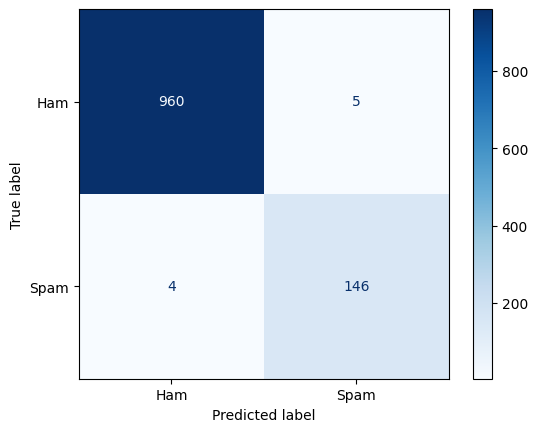


              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       965
         1.0       0.97      0.97      0.97       150

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_tensor.cpu(),
    predictions.cpu(),
    display_labels=['Ham', 'Spam'],
    cmap=plt.cm.Blues
)

plt.show()
print()
print(classification_report(y_test_tensor.cpu(),predictions.cpu()))